In [188]:
import pandas as pd

df = pd.read_csv('../../../datasets/housing.csv')
df_eda = df

In [189]:
df_eda.isnull().sum().sum()

np.int64(207)

In [190]:
df_eda.dropna(inplace = True)
df_eda.isnull().sum().sum()

np.int64(0)

In [191]:
df_eda.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

### EDA (FEATURES SELECTIONS)

In [192]:
df_eda.drop(columns=['ocean_proximity'], axis= 1, inplace= True)
X = df_eda.drop(columns=['median_house_value'])
y = df_eda['median_house_value']


median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64


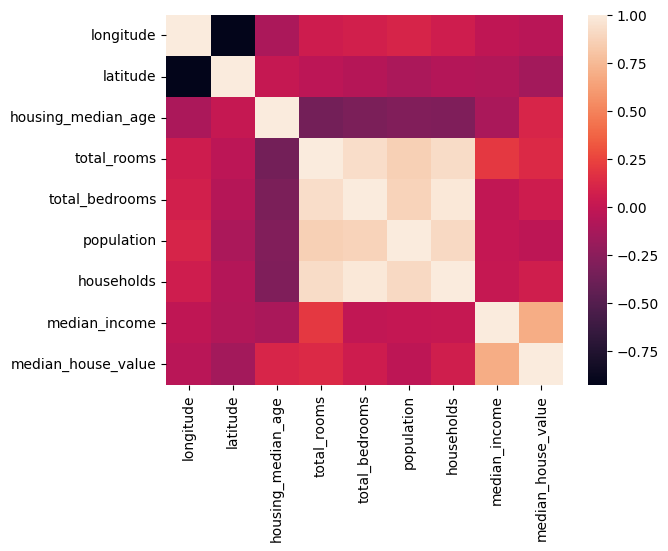

In [193]:
corr = df_eda.corr()

print(corr['median_house_value'].sort_values(ascending= False))

import seaborn as sns
sns.heatmap(corr);



In [194]:
# SELECT KBEST

from sklearn.feature_selection import SelectKBest, f_regression



# Train the model to get the best columns
skselector = SelectKBest(score_func=f_regression, k = 5)
skselector.fit_transform(X, y)

# Get the columns names
kbest_columns = X.columns[skselector.get_support()]




In [195]:
# VARIANCE THRESHOLD


from sklearn.feature_selection import VarianceThreshold


# Get the filter and train
variance_features = VarianceThreshold(threshold=0.16)
variance_features.fit_transform(X)

# Get the columns
variance_columns = X.columns[variance_features.get_support()]


In [196]:
# RFE

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression


# Get the models
model = LinearRegression()
rfe_selector = RFE(model, n_features_to_select=5)

# Train and get the features name
rfe_selector.fit(X, y)
rfe_columns = X.columns[rfe_selector.get_support()]


In [ ]:
# SFS

from sklearn.feature_selection import SequentialFeatureSelector

# Get the model and train
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward', cv=5)
sfs.fit(X, y)

# Get the features names
sfs_columns = X.columns[sfs.get_support()]


In [ ]:
# SFM

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

# 1. Escolha um modelo que saiba dar notas às colunas
model = RandomForestRegressor(n_estimators=100)
selector = SelectFromModel(model, threshold='mean')
selector.fit(X, y)


sfm_columns = X.columns[selector.get_support()]

In [201]:
print(f"Columns KBest:  {kbest_columns.tolist()}")
print(f"Columns Variance: {variance_columns.tolist()}")
print(f"Columns RFE: {rfe_columns.tolist()}")
print(f"Columns SFS: {sfs_columns.tolist()}")
print(f"Columns Select from Model (SFM): {sfm_columns.tolist()}")

Columns KBest:  ['latitude', 'housing_median_age', 'total_rooms', 'households', 'median_income']
Columns Variance: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Columns RFE: ['longitude', 'latitude', 'housing_median_age', 'total_bedrooms', 'median_income']
Columns SFS: ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'median_income']
Columns Select from Model (SFM): ['longitude', 'latitude', 'median_income']
